<div style="display:block;width:100%;margin:auto;" direction=rtl align=center><br><br>
    <div  style="width:100%;margin:100;display:block;background-color:#fff0;"  display=block align=center>
        <table style="border-style:hidden;border-collapse:collapse;">             <tr>
                <td  style="border: none!important;">
                    <img width=130 align=right src="https://i.ibb.co/yXKQmtZ/logo1.png" style="margin:0;" />
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>Armin Ghasemi</b><br><br>810100198</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b> ML </b><br><br>HW3_Q4</i></font></h1>
                </td>
                <td style="text-align:center;border: none!important;">
                    <h1 align=center><font size=5 color="#045F5F"> <b>  </b><br><br></i></font></h1>
                </td>
                <td style="border: none!important;">
                    <img width=170 align=left  src="https://i.ibb.co/wLjqFkw/logo2.png" style="margin:0;" />
                </td>
           </tr>
        </table>
    </div>
</div>


# 📉 Optimization Algorithms from Scratch
### Steepest Descent vs. Newton's Method on Rosenbrock Function

> **Course:** Machine Learning | University of Tehran
> **Assignment:** Homework 3 - Question 4
> **Topic:** Convex & Non-Convex Optimization

---

## 📝 Problem Statement
The objective is to find the global minimum of the famous **Rosenbrock Function** (also known as the Valley or Banana function), defined as:
$$f(x) = 100(x_2 - x_1^2)^2 + (1 - x_1)^2$$

We aim to implement and compare two fundamental optimization strategies manually:
1.  **Steepest Descent (Gradient Descent):** First-order optimization.
2.  **Newton's Method:** Second-order optimization (using Hessian).

**Key Objectives:**
* Compute **Gradient** vector ($\nabla f$) and **Hessian** matrix ($H$) symbolically.
* Implement optimization loops from scratch using `NumPy`.
* Compare convergence speed and path of both algorithms starting from $x_0 = [-4, 10]^T$.
* **Hybrid Approach:** Combine both methods to leverage the stability of GD and the speed of Newton.
* Visualize the optimization trajectory and convergence rates.

---

### Imports

In [238]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

### a)define function:

In [239]:

x1, x2 = sp.symbols('x1 x2')
f =  (100*((x2 - (x1**2))**2) + (1-x1)**2)

### b)Calculating the gradient and Hessian:

In [240]:

grad_f = [sp.diff(f, var) for var in (x1, x2)]
hessian_f = [[sp.diff(g, var) for var in (x1, x2)] for g in grad_f]

print("Gradient of f:")
print(f"[{grad_f[0]}]")
print(f"[{grad_f[1]}]")
print("Hessian of f:")
print(hessian_f[0])
print(hessian_f[1])


Gradient of f:
[-400*x1*(-x1**2 + x2) + 2*x1 - 2]
[-200*x1**2 + 200*x2]
Hessian of f:
[1200*x1**2 - 400*x2 + 2, -400*x1]
[-400*x1, 200]


### c)define gradient and Hessian:

In [241]:
def f(x1, x2):
    return (100*((x2 - (x1**2))**2) + (1-x1)**2)

def gradient_f(x1, x2):
    return np.array([(-400*x1*(-x1**2 + x2) + 2*x1 - 2), (-200*x1**2 + 200*x2)])

def hessian_f(x1, x2):
    return np.array([[(1200*x1**2 - 400*x2 + 2), (-400*x1)] , [-400*x1, 200]])

### d)Steepest-Decent:

In [242]:
x_k = np.array([-4.0 , 10])
max_iter =10000000
learning_rate = 0.0001
values_s = [] 
points_s = []
distances_s =[]
values_s.append(f(x_k[0],x_k[1]))
points_s.append(x_k)
for i in range(max_iter):
    grad = gradient_f(x_k[0] , x_k[1])
    x_k = x_k - learning_rate * grad 
    values_s.append(f(x_k[0],x_k[1]))
    points_s.append(x_k)

for i in range(max_iter+1):
    distances_s.append(np.linalg.norm(points_s[i] - x_k))

print(f"f({x_k}) = {f(x_k[0],x_k[1])}")

f([1. 1.]) = 6.941051519571598e-25


### e)Newton

In [243]:
x_k = np.array([-4.0 , 10])
max_iter =6
values_n = [] 
values_n.append(f(x_k[0],x_k[1]))
points_n = []
distances_n =[]
points_n.append(x_k)
for i in range(max_iter):
    grad = gradient_f(x_k[0] , x_k[1])
    hess_inv = np.linalg.inv(hessian_f(x_k[0] , x_k[1]))
    x_k = x_k - hess_inv @ grad 
    values_n.append(f(x_k[0],x_k[1]))
    points_n.append(x_k)

for i in range(max_iter+1):
    distances_n.append(np.linalg.norm(points_n[i] - x_k))

print(f"f({x_k}) = {f(x_k[0],x_k[1])}")


f([1. 1.]) = 3.865418435582958e-29


### f)Steepest-Decent & Newton:

In [244]:
x_k = np.array([-4.0 , 10])
max_iter =500000
learning_rate = 0.0001
points_sn = []
distances_sn =[]
values_sn = [] 

values_sn.append(f(x_k[0],x_k[1]))
points_sn.append(x_k)

for i in range(max_iter):
    grad = gradient_f(x_k[0] , x_k[1])
    x_k = x_k - learning_rate * grad 
    values_sn.append(f(x_k[0],x_k[1]))
    points_sn.append(x_k)

grad = gradient_f(x_k[0] , x_k[1])
hess_inv = np.linalg.inv(hessian_f(x_k[0] , x_k[1]))
x_k = x_k - hess_inv @ grad 
values_sn.append(f(x_k[0],x_k[1]))
points_sn.append(x_k)

for i in range(max_iter+2):
    distances_sn.append(np.linalg.norm(points_sn[i] - x_k))

print(f"f({x_k}) = {f(x_k[0],x_k[1])}")


f([1. 1.]) = 4.942706609275402e-30


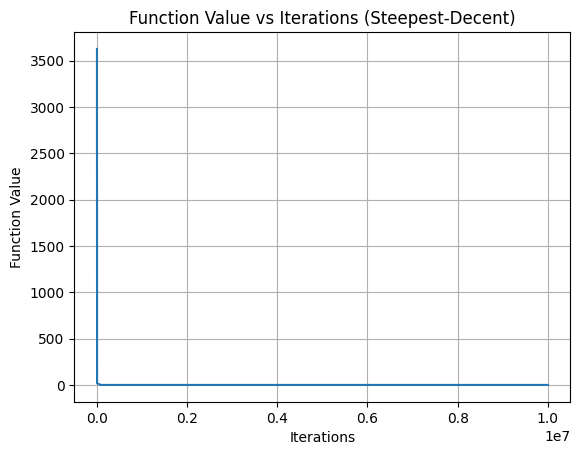

In [245]:
iterations = np.arange(len(values_s))

plt.plot(iterations, values_s, label='Function Value')
plt.xlabel('Iterations')
plt.ylabel('Function Value')
plt.title('Function Value vs Iterations (Steepest-Decent)')
plt.grid(True)


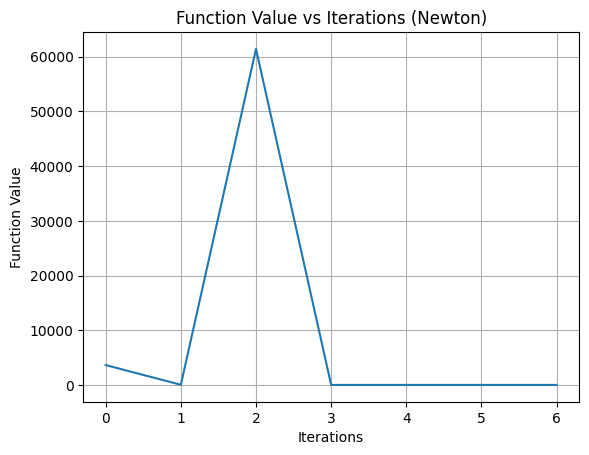

In [246]:
iterations = np.arange(len(values_n))

plt.plot(iterations, values_n, label='Function Value')
plt.xlabel('Iterations')
plt.ylabel('Function Value')
plt.title('Function Value vs Iterations (Newton)')
plt.grid(True)

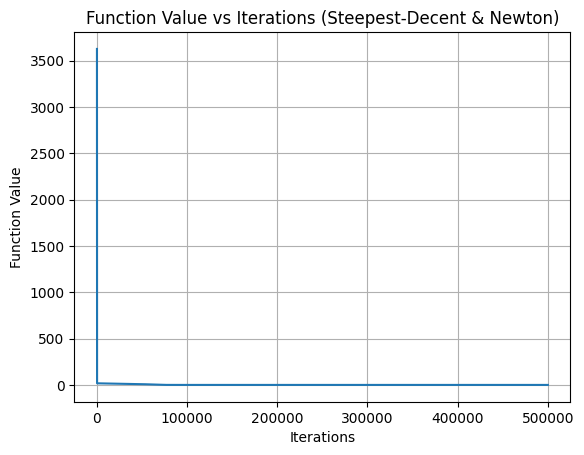

In [247]:
iterations = np.arange(len(values_sn))

plt.plot(iterations, values_sn, label='Function Value')
plt.xlabel('Iterations')
plt.ylabel('Function Value')
plt.title('Function Value vs Iterations (Steepest-Decent & Newton)')
plt.grid(True)

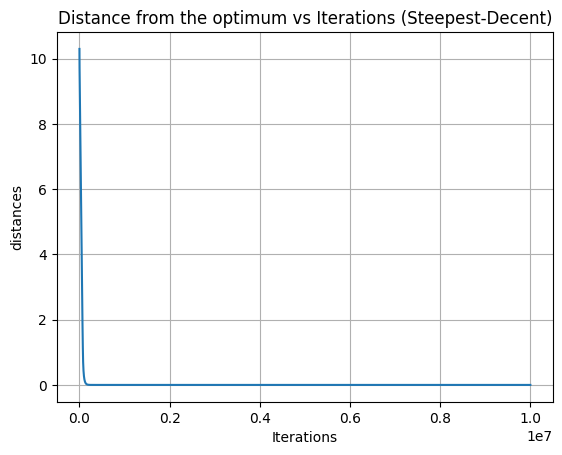

In [248]:
iterations = np.arange(len(distances_s))

plt.plot(iterations, distances_s, label='distances')
plt.xlabel('Iterations')
plt.ylabel('distances')
plt.title('Distance from the optimum vs Iterations (Steepest-Decent)')
plt.grid(True)


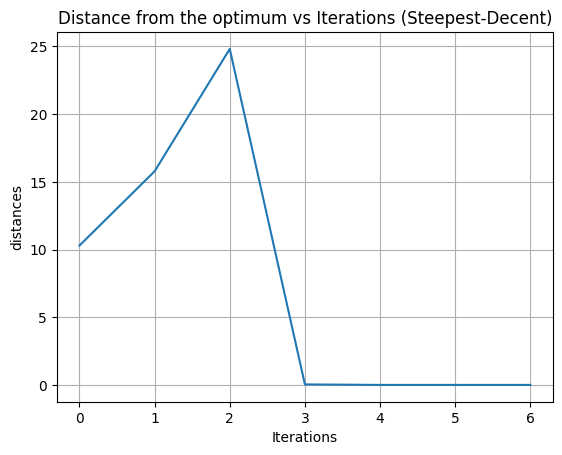

In [250]:
iterations = np.arange(len(distances_n))

plt.plot(iterations, distances_n, label='distances')
plt.xlabel('Iterations')
plt.ylabel('distances')
plt.title('Distance from the optimum vs Iterations (Steepest-Decent)')
plt.grid(True)

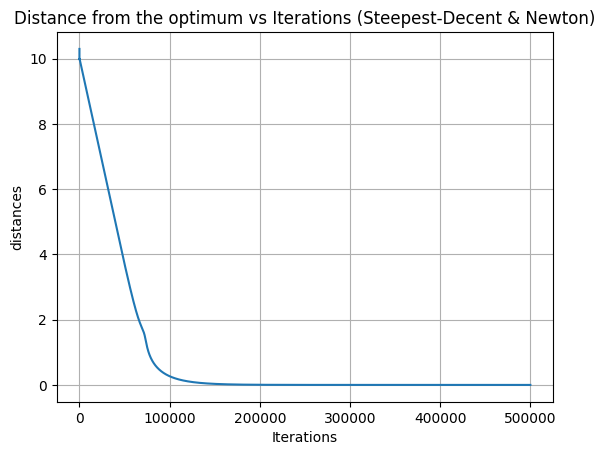

In [249]:
iterations = np.arange(len(distances_sn))

plt.plot(iterations, distances_sn, label='distances')
plt.xlabel('Iterations')
plt.ylabel('distances')
plt.title('Distance from the optimum vs Iterations (Steepest-Decent & Newton)')
plt.grid(True)